# Feature Diagnostics Test

This notebook runs `run_single_case_features_Sharpe` and keeps the strategy object after the run, so the per-date feature-selection diagnostics can be inspected and plotted.

It assumes `run_single_case_features_Sharpe(..., return_strategy=True)` is available. If your runner does not expose that yet, see the final markdown cell for the small change needed.

In [1]:
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

from run_single_case_features_Sharpe import run_single_case_features_Sharpe


def play_sound(name="Glass"):
    # Optional macOS completion sound for longer runs.
    import subprocess
    subprocess.run(["afplay", f"/System/Library/Sounds/{name}.aiff"], check=False)

## Paramter set 1

### Run One Sharpe-Filtered Case

The important bit is `return_strategy=True`. The feature diagnostics are stored on the strategy instance during `generate_signals()`.

🧠 Predicting 2025-12-31 |  250/250 |  last: 0.31s |  elapsed: 1m 38.8s
✅ Prediction complete. Took 1m 39.1s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward ---
   Frictionless Return: 38.01%
   Net Strategy Return: 32.66% (EW Benchmark: 65.17%)
   Max Drawdown:        -14.29%
   Win Rate (Gross Bars):     52.4% (EW Benchmark (Bars): 54.4%)
   Loss Rate (Gross Bars):    44.4% (EW Benchmark (Bars): 42.8%)
   Total Fees Paid:     $53,416.15
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/src/research/Tearsheets/ECH_ML_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


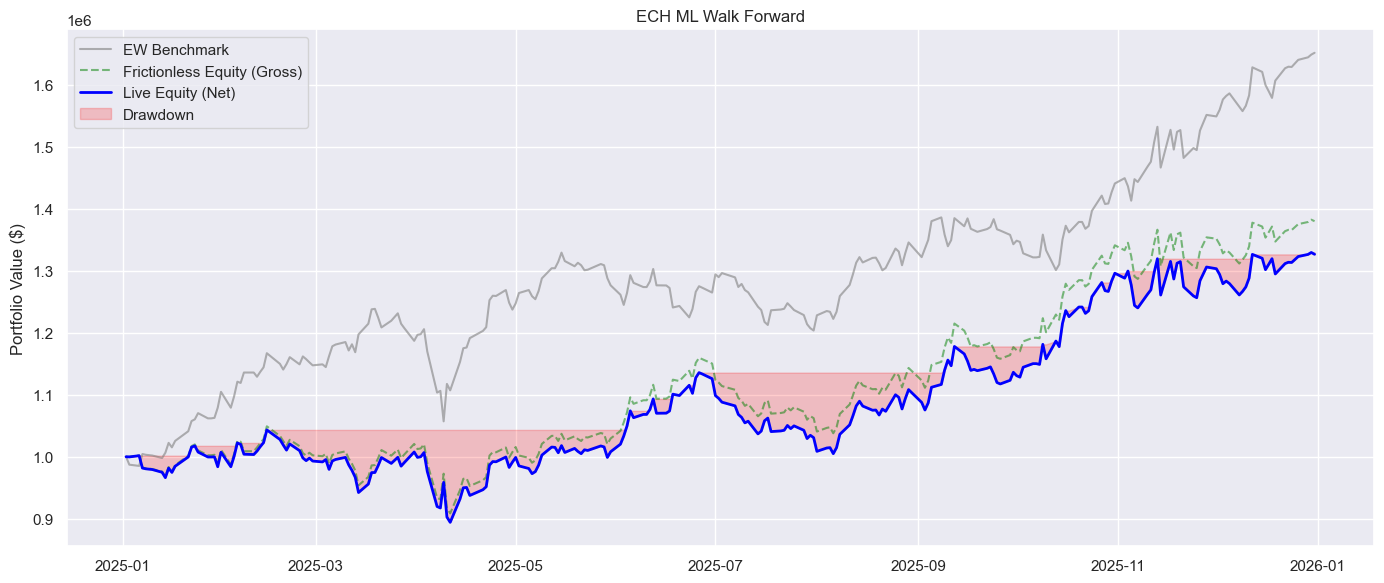

{'symbol': 'ECH',
 'start_date': '2025-01-01',
 'end_date': '2026-01-01',
 'signal_threshold': 0.002,
 'n_features': 13,
 'training_years': 10,
 'rolling_sharpe_window': 63,
 'sharpe_enter_threshold': 1.05,
 'sharpe_exit_threshold': 0.95,
 'sharpe_filter_enabled': False,
 'rolling_sharpe_min_periods': 63,
 'rolling_sharpe_annualization': 252,
 'sharpe_performance_lag': 2,
 'feature_diagnostics_enabled': True,
 'feature_diagnostics_top_n': None,
 'position_size': 1.0,
 'max_iter': 5000,
 'verbose': False,
 'show_progress': True}

In [2]:
case_params = dict(
    symbol = "ECH",
    asset_class = "STK",
    start_date = "2025-01-01",
    end_date = "2026-01-01",
    signal_threshold = 0.002,
    n_features = 13,
    training_years = 10,
    sharpe_filter_enabled = False,
    # rolling_sharpe_window = 63,
    # sharpe_enter_threshold = 1.05,
    # sharpe_exit_threshold = 0.95,
)

# Ask the runner to return both params and the strategy object for diagnostics.
run_output = run_single_case_features_Sharpe(
    **case_params,
    return_params = True,
    return_strategy = True,
)

# Current recommended runner behavior is a dict when both return flags are True.
params = run_output["params"]
strategy = run_output["strategy"]

display(params)

In [3]:
# Optional: play a sound once the run completes.
play_sound()

### Raw Feature Diagnostics

`feature_selection_diagnostics_` is one row per prediction date and feature rank. The column `selected` tells you whether that feature was actually passed through to the MLP on that date.

In [4]:
# Copy diagnostics and keep only the configured prediction window.
diagnostics = strategy.feature_selection_diagnostics_.copy()
diagnostics["prediction_date"] = pd.to_datetime(diagnostics["prediction_date"])

start = pd.to_datetime(strategy.start_date)
end = pd.to_datetime(strategy.end_date)

prediction_window_diagnostics = diagnostics[
    diagnostics["prediction_date"].between(start, end)
].copy()

print(f"All diagnostic rows: {len(diagnostics):,}")
print(f"Prediction-window diagnostic rows: {len(prediction_window_diagnostics):,}")
display(prediction_window_diagnostics.head(20))

All diagnostic rows: 108,190
Prediction-window diagnostic rows: 108,190


,prediction_date,feature,pearson_abs_corr,rank,selected
0,2025-01-02,BOP,0.115531,1,True
1,2025-01-02,CDL_BELTHOLD,0.102702,2,True
2,2025-01-02,CDL_LONGLINE,0.099895,3,True
3,2025-01-02,DEC_1,0.092500,4,True
4,2025-01-02,DEC_2,0.092500,5,True
5,2025-01-02,SDEC_2,0.092500,6,True
6,2025-01-02,INC_2,0.086593,7,True
7,2025-01-02,INC_1,0.086593,8,True
8,2025-01-02,SINC_2,0.086593,9,True
9,2025-01-02,BBP_5_2.0,0.083229,10,True


### Features Selected Each Day

`selected_features_by_date_` is the direct date-to-list view: one date maps to the exact features selected by `SelectKBest` and passed to the MLP.

In [5]:
# Convert the date -> list dictionary into a compact DataFrame.
selected_features_by_date = {
    pd.to_datetime(date): features
    for date, features in strategy.selected_features_by_date_.items()
    if start <= pd.to_datetime(date) <= end
}

selected_features_df = pd.DataFrame([
    {
        "prediction_date": date,
        "n_selected_features": len(features),
        "selected_features": features,
    }
    for date, features in selected_features_by_date.items()
]).sort_values("prediction_date")

display(selected_features_df.head(10))
display(selected_features_df.tail(10))

,prediction_date,n_selected_features,selected_features
0,2025-01-02,13,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_CLOSINGMARU..."
1,2025-01-03,13,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_CLOSINGMARU..."
2,2025-01-06,13,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_CLOSINGMARU..."
3,2025-01-07,13,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_CLOSINGMARU..."
4,2025-01-08,13,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_CLOSINGMARU..."
5,2025-01-10,13,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_CLOSINGMARU..."
6,2025-01-13,13,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_CLOSINGMARU..."
7,2025-01-14,13,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_CLOSINGMARU..."
8,2025-01-15,13,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_CLOSINGMARU..."
9,2025-01-16,13,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_CLOSINGMARU..."


,prediction_date,n_selected_features,selected_features
240,2025-12-17,13,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_LONGLINE, D..."
241,2025-12-18,13,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_LONGLINE, D..."
242,2025-12-19,13,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_LONGLINE, D..."
243,2025-12-22,13,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_LONGLINE, D..."
244,2025-12-23,13,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_LONGLINE, D..."
245,2025-12-24,13,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_LONGLINE, D..."
246,2025-12-26,13,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_LONGLINE, D..."
247,2025-12-29,13,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_LONGLINE, D..."
248,2025-12-30,13,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_LONGLINE, D..."
249,2025-12-31,13,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_LONGLINE, D..."


### Feature Selection Frequency Plot

This plots the most frequently selected features. If `plot_feature_frequency()` has the prediction-window default fix, this excludes any Sharpe warm-up diagnostics automatically.

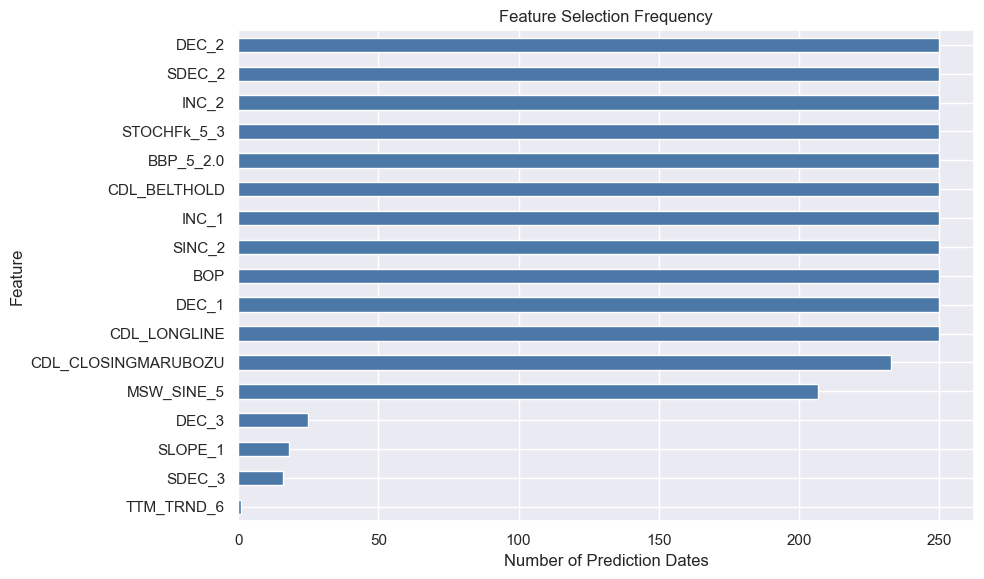

In [6]:
# Frequency graph of selected features in the configured prediction window.
ax = strategy.plot_feature_frequency(top_n=30, selected_only=True)
plt.show()

### Frequency Table

The table view is useful when you want exact counts and shares instead of only the plot.

In [7]:
# Count selected-feature frequency across prediction dates.
selected_rows = prediction_window_diagnostics[prediction_window_diagnostics["selected"]].copy()
n_prediction_dates = selected_rows["prediction_date"].nunique()

feature_frequency = selected_rows["feature"].value_counts().rename("selected_days").to_frame()
feature_frequency["selected_share"] = feature_frequency["selected_days"] / n_prediction_dates

display(feature_frequency.head(30))

,selected_days,selected_share
feature,,
BOP,250,1.000
INC_2,250,1.000
STOCHFk_5_3,250,1.000
BBP_5_2.0,250,1.000
CDL_BELTHOLD,250,1.000
INC_1,250,1.000
SINC_2,250,1.000
SDEC_2,250,1.000
DEC_2,250,1.000


### Highest-Correlating Features

This summarizes the absolute Pearson correlation scores recorded by `SelectKBest`. These are training-window scores, recomputed for each prediction date.

In [8]:
# Summarize feature scores across dates.
score_summary = (
    prediction_window_diagnostics
    .groupby("feature")
    .agg(
        mean_abs_corr=("pearson_abs_corr", "mean"),
        median_abs_corr=("pearson_abs_corr", "median"),
        selected_days=("selected", "sum"),
        seen_days=("prediction_date", "nunique"),
    )
    .sort_values(["selected_days", "mean_abs_corr"], ascending=False)
)

display(score_summary.head(30))

,mean_abs_corr,median_abs_corr,selected_days,seen_days
feature,,,,
BOP,0.109346,0.108702,250,250
CDL_LONGLINE,0.099431,0.098661,250,250
CDL_BELTHOLD,0.094890,0.094297,250,250
DEC_1,0.084739,0.084183,250,250
DEC_2,0.084739,0.084183,250,250
SDEC_2,0.084739,0.084183,250,250
INC_1,0.080458,0.080076,250,250
INC_2,0.080458,0.080076,250,250
SINC_2,0.080458,0.080076,250,250


### Inspect One Prediction Date

Use this to see the ranked feature scores for a specific model fit.

In [9]:
# Change this date to inspect another daily model fit.
date_to_check = selected_features_df["prediction_date"].iloc[0]

one_day_features = (
    prediction_window_diagnostics[prediction_window_diagnostics["prediction_date"].eq(date_to_check)]
    .sort_values("rank")
)

print(date_to_check.date())
display(one_day_features)

2025-01-02


,prediction_date,feature,pearson_abs_corr,rank,selected
0,2025-01-02,BOP,0.115531,1,True
1,2025-01-02,CDL_BELTHOLD,0.102702,2,True
2,2025-01-02,CDL_LONGLINE,0.099895,3,True
3,2025-01-02,DEC_1,0.092500,4,True
4,2025-01-02,DEC_2,0.092500,5,True
...,...,...,...,...,...
428,2025-01-02,SINC_10,0.000120,429,False
429,2025-01-02,INC_10,0.000120,430,False
430,2025-01-02,CDL_STICKSANDWICH,0.000120,431,False
431,2025-01-02,TSIs_13_25_13,0.000096,432,False


In [10]:
play_sound()

## Paramter set 2

### Run One Sharpe-Filtered Case

The important bit is `return_strategy=True`. The feature diagnostics are stored on the strategy instance during `generate_signals()`.

🧠 Predicting 2025-12-31 |  250/250 |  last: 0.66s |  elapsed: 2m 29.2s
✅ Prediction complete. Took 2m 29.9s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward ---
   Frictionless Return: 59.08%
   Net Strategy Return: 52.81% (EW Benchmark: 65.17%)
   Max Drawdown:        -10.29%
   Win Rate (Gross Bars):     54.8% (EW Benchmark (Bars): 54.4%)
   Loss Rate (Gross Bars):    40.8% (EW Benchmark (Bars): 42.8%)
   Total Fees Paid:     $62,716.48
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/src/research/Tearsheets/ECH_ML_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


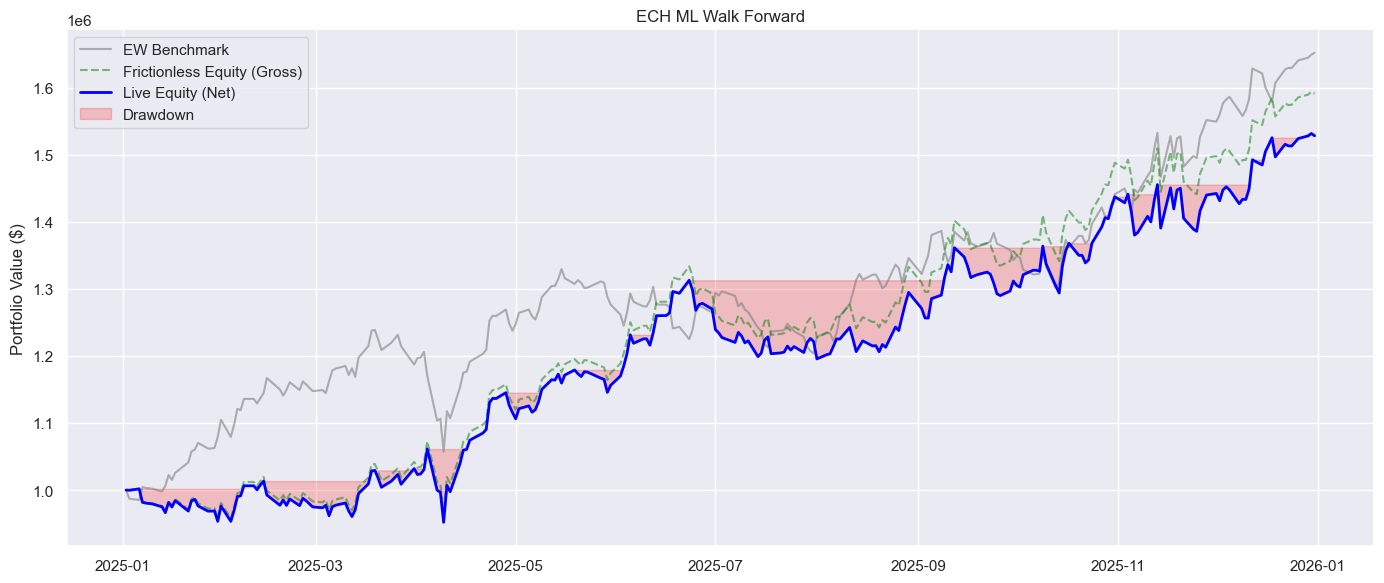

{'symbol': 'ECH',
 'start_date': '2025-01-01',
 'end_date': '2026-01-01',
 'signal_threshold': 0.003,
 'n_features': 15,
 'training_years': 10,
 'rolling_sharpe_window': 63,
 'sharpe_enter_threshold': 1.05,
 'sharpe_exit_threshold': 0.95,
 'sharpe_filter_enabled': False,
 'rolling_sharpe_min_periods': 63,
 'rolling_sharpe_annualization': 252,
 'sharpe_performance_lag': 2,
 'feature_diagnostics_enabled': True,
 'feature_diagnostics_top_n': None,
 'position_size': 1.0,
 'max_iter': 5000,
 'verbose': False,
 'show_progress': True}

In [11]:
case_params = dict(
    symbol = "ECH",
    asset_class = "STK",
    start_date = "2025-01-01",
    end_date = "2026-01-01",
    signal_threshold = 0.003,
    n_features = 15,
    training_years = 10,
    sharpe_filter_enabled = False,
    # rolling_sharpe_window = 63,
    # sharpe_enter_threshold = 1.05,
    # sharpe_exit_threshold = 0.95,
)

# Ask the runner to return both params and the strategy object for diagnostics.
run_output = run_single_case_features_Sharpe(
    **case_params,
    return_params = True,
    return_strategy = True,
)

# Current recommended runner behavior is a dict when both return flags are True.
params = run_output["params"]
strategy = run_output["strategy"]

display(params)

In [12]:
# Optional: play a sound once the run completes.
play_sound()

### Raw Feature Diagnostics

`feature_selection_diagnostics_` is one row per prediction date and feature rank. The column `selected` tells you whether that feature was actually passed through to the MLP on that date.

In [13]:
# Copy diagnostics and keep only the configured prediction window.
diagnostics = strategy.feature_selection_diagnostics_.copy()
diagnostics["prediction_date"] = pd.to_datetime(diagnostics["prediction_date"])

start = pd.to_datetime(strategy.start_date)
end = pd.to_datetime(strategy.end_date)

prediction_window_diagnostics = diagnostics[
    diagnostics["prediction_date"].between(start, end)
].copy()

print(f"All diagnostic rows: {len(diagnostics):,}")
print(f"Prediction-window diagnostic rows: {len(prediction_window_diagnostics):,}")
display(prediction_window_diagnostics.head(20))

All diagnostic rows: 108,190
Prediction-window diagnostic rows: 108,190


,prediction_date,feature,pearson_abs_corr,rank,selected
0,2025-01-02,BOP,0.098966,1,True
1,2025-01-02,CDL_LONGLINE,0.085662,2,True
2,2025-01-02,DEC_1,0.085441,3,True
3,2025-01-02,DEC_2,0.085441,4,True
4,2025-01-02,SDEC_2,0.085441,5,True
5,2025-01-02,CDL_BELTHOLD,0.085139,6,True
6,2025-01-02,SINC_2,0.079369,7,True
7,2025-01-02,INC_2,0.079369,8,True
8,2025-01-02,INC_1,0.079369,9,True
9,2025-01-02,BBP_5_2.0,0.072855,10,True


### Features Selected Each Day

`selected_features_by_date_` is the direct date-to-list view: one date maps to the exact features selected by `SelectKBest` and passed to the MLP.

In [14]:
# Convert the date -> list dictionary into a compact DataFrame.
selected_features_by_date = {
    pd.to_datetime(date): features
    for date, features in strategy.selected_features_by_date_.items()
    if start <= pd.to_datetime(date) <= end
}

selected_features_df = pd.DataFrame([
    {
        "prediction_date": date,
        "n_selected_features": len(features),
        "selected_features": features,
    }
    for date, features in selected_features_by_date.items()
]).sort_values("prediction_date")

display(selected_features_df.head(10))
display(selected_features_df.tail(10))

,prediction_date,n_selected_features,selected_features
0,2025-01-02,15,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_LONGLINE, D..."
1,2025-01-03,15,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_LONGLINE, D..."
2,2025-01-06,15,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_LONGLINE, D..."
3,2025-01-07,15,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_CLOSINGMARU..."
4,2025-01-08,15,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_CLOSINGMARU..."
5,2025-01-10,15,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_CLOSINGMARU..."
6,2025-01-13,15,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_CLOSINGMARU..."
7,2025-01-14,15,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_CLOSINGMARU..."
8,2025-01-15,15,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_CLOSINGMARU..."
9,2025-01-16,15,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_CLOSINGMARU..."


,prediction_date,n_selected_features,selected_features
240,2025-12-17,15,"[AVOLUME_20, BBP_5_2.0, BOP, CDL_BELTHOLD, CDL..."
241,2025-12-18,15,"[AVOLUME_20, BBP_5_2.0, BOP, CDL_BELTHOLD, CDL..."
242,2025-12-19,15,"[AVOLUME_20, BBP_5_2.0, BOP, CDL_BELTHOLD, CDL..."
243,2025-12-22,15,"[AVOLUME_20, BBP_5_2.0, BOP, CDL_BELTHOLD, CDL..."
244,2025-12-23,15,"[AVOLUME_20, BBP_5_2.0, BOP, CDL_BELTHOLD, CDL..."
245,2025-12-24,15,"[AVOLUME_20, BBP_5_2.0, BOP, CDL_BELTHOLD, CDL..."
246,2025-12-26,15,"[AVOLUME_20, BBP_5_2.0, BOP, CDL_BELTHOLD, CDL..."
247,2025-12-29,15,"[AVOLUME_20, BBP_5_2.0, BOP, CDL_BELTHOLD, CDL..."
248,2025-12-30,15,"[AVOLUME_20, BBP_5_2.0, BOP, CDL_BELTHOLD, CDL..."
249,2025-12-31,15,"[AVOLUME_20, BBP_5_2.0, BOP, CDL_BELTHOLD, CDL..."


### Feature Selection Frequency Plot

This plots the most frequently selected features. If `plot_feature_frequency()` has the prediction-window default fix, this excludes any Sharpe warm-up diagnostics automatically.

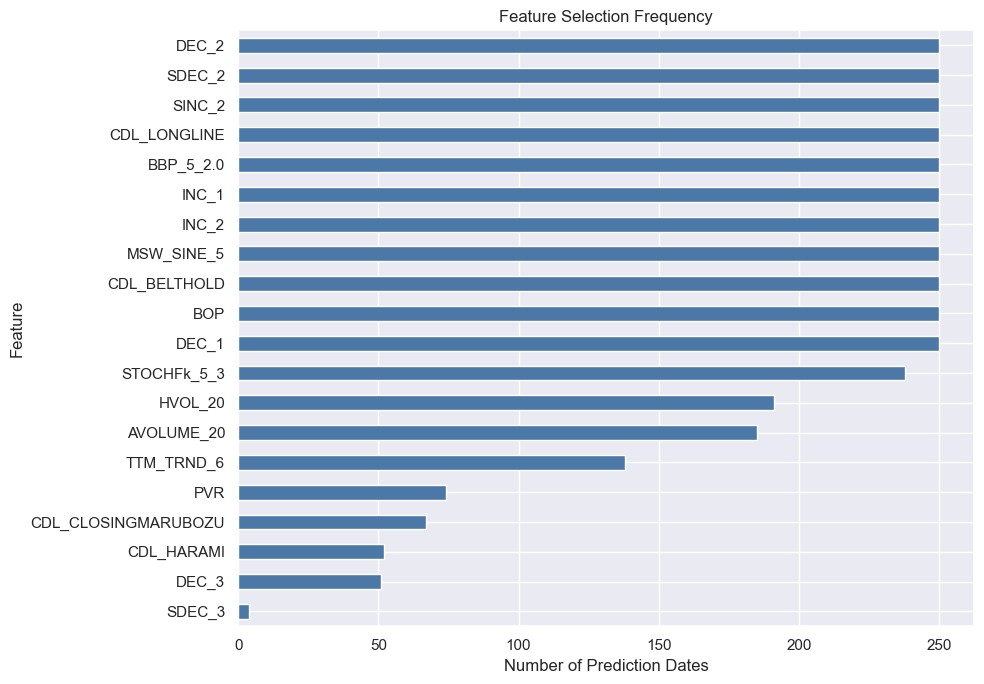

In [15]:
# Frequency graph of selected features in the configured prediction window.
ax = strategy.plot_feature_frequency(top_n=30, selected_only=True)
plt.show()

### Frequency Table

The table view is useful when you want exact counts and shares instead of only the plot.

In [16]:
# Count selected-feature frequency across prediction dates.
selected_rows = prediction_window_diagnostics[prediction_window_diagnostics["selected"]].copy()
n_prediction_dates = selected_rows["prediction_date"].nunique()

feature_frequency = selected_rows["feature"].value_counts().rename("selected_days").to_frame()
feature_frequency["selected_share"] = feature_frequency["selected_days"] / n_prediction_dates

display(feature_frequency.head(30))

,selected_days,selected_share
feature,,
BOP,250,1.000
SINC_2,250,1.000
CDL_LONGLINE,250,1.000
BBP_5_2.0,250,1.000
INC_1,250,1.000
INC_2,250,1.000
MSW_SINE_5,250,1.000
CDL_BELTHOLD,250,1.000
SDEC_2,250,1.000


### Highest-Correlating Features

This summarizes the absolute Pearson correlation scores recorded by `SelectKBest`. These are training-window scores, recomputed for each prediction date.

In [17]:
# Summarize feature scores across dates.
score_summary = (
    prediction_window_diagnostics
    .groupby("feature")
    .agg(
        mean_abs_corr=("pearson_abs_corr", "mean"),
        median_abs_corr=("pearson_abs_corr", "median"),
        selected_days=("selected", "sum"),
        seen_days=("prediction_date", "nunique"),
    )
    .sort_values(["selected_days", "mean_abs_corr"], ascending=False)
)

display(score_summary.head(30))

,mean_abs_corr,median_abs_corr,selected_days,seen_days
feature,,,,
BOP,0.092210,0.092268,250,250
CDL_LONGLINE,0.084300,0.084075,250,250
DEC_1,0.077779,0.078448,250,250
DEC_2,0.077779,0.078448,250,250
SDEC_2,0.077779,0.078448,250,250
CDL_BELTHOLD,0.077084,0.077538,250,250
INC_1,0.073413,0.074270,250,250
INC_2,0.073413,0.074270,250,250
SINC_2,0.073413,0.074270,250,250


### Inspect One Prediction Date

Use this to see the ranked feature scores for a specific model fit.

In [ ]:
# Change this date to inspect another daily model fit.
date_to_check = selected_features_df["prediction_date"].iloc[0]

one_day_features = (
    prediction_window_diagnostics[prediction_window_diagnostics["prediction_date"].eq(date_to_check)]
    .sort_values("rank")
)

print(date_to_check.date())
display(one_day_features)

2024-01-02


,prediction_date,feature,pearson_abs_corr,rank,selected
0,2024-01-02,BOP,0.103608,1,True
1,2024-01-02,DEC_2,0.093959,2,True
2,2024-01-02,SDEC_2,0.093959,3,True
3,2024-01-02,DEC_1,0.093959,4,True
4,2024-01-02,INC_2,0.090340,5,True
...,...,...,...,...,...
427,2024-01-02,SINC_10,0.000050,428,False
428,2024-01-02,INC_10,0.000050,429,False
429,2024-01-02,CDL_TRISTAR,0.000047,430,False
430,2024-01-02,CDL_3WHITESOLDIERS,0.000035,431,False


In [ ]:
play_sound()

## Paramter set 3

### Run One Sharpe-Filtered Case

The important bit is `return_strategy=True`. The feature diagnostics are stored on the strategy instance during `generate_signals()`.

🧠 Predicting 2024-12-31 |  252/252 |  last: 0.75s |  elapsed: 2m 19.1s
✅ Prediction complete. Took 2m 19.8s


📊 --- QUICK PORTFOLIO RESULTS: ECH ML Walk Forward ---
   Frictionless Return: 9.03%
   Net Strategy Return: 2.35% (EW Benchmark: -7.55%)
   Max Drawdown:        -21.09%
   Win Rate (Gross Bars):     52.0% (EW Benchmark (Bars): 49.2%)
   Loss Rate (Gross Bars):    44.8% (EW Benchmark (Bars): 49.6%)
   Total Fees Paid:     $66,856.96
---------------------------------------------
📈 Generating Institutional Tearsheet (quantstats)...
✅ Tearsheet saved successfully to: /Users/mateo/Bluegrey/src/research/Tearsheets/ECH_ML_Walk_Forward_tearsheet.html
   (Open this file in your web browser to view Sharpe, Drawdowns, etc.)


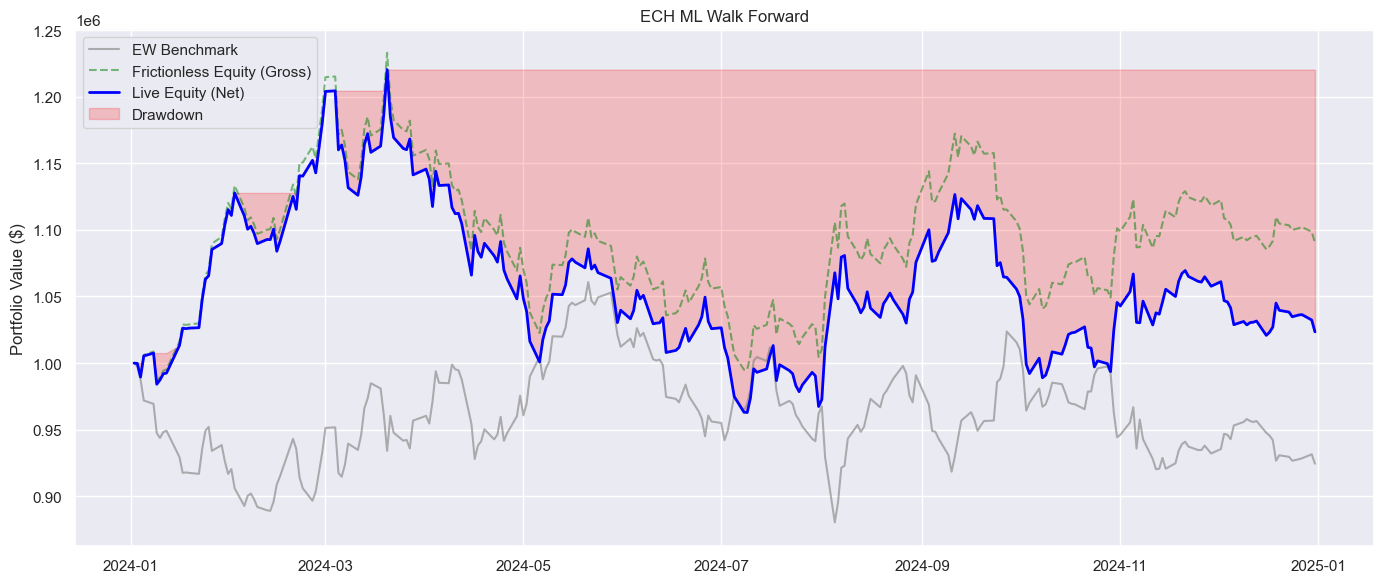

{'symbol': 'ECH',
 'start_date': '2024-01-01',
 'end_date': '2025-01-01',
 'signal_threshold': 0.003,
 'n_features': 15,
 'training_years': 10,
 'rolling_sharpe_window': 63,
 'sharpe_enter_threshold': 1.05,
 'sharpe_exit_threshold': 0.95,
 'sharpe_filter_enabled': False,
 'rolling_sharpe_min_periods': 63,
 'rolling_sharpe_annualization': 252,
 'sharpe_performance_lag': 2,
 'feature_diagnostics_enabled': True,
 'feature_diagnostics_top_n': None,
 'position_size': 1.0,
 'max_iter': 5000,
 'verbose': False,
 'show_progress': True}

In [20]:
case_params = dict(
    symbol = "ECH",
    asset_class = "STK",
    start_date = "2024-01-01",
    end_date = "2025-01-01",
    signal_threshold = 0.003,
    n_features = 15,
    training_years = 10,
    sharpe_filter_enabled = False,
    # rolling_sharpe_window = 63,
    # sharpe_enter_threshold = 1.05,
    # sharpe_exit_threshold = 0.95,
)

# Ask the runner to return both params and the strategy object for diagnostics.
run_output = run_single_case_features_Sharpe(
    **case_params,
    return_params = True,
    return_strategy = True,
)

# Current recommended runner behavior is a dict when both return flags are True.
params = run_output["params"]
strategy = run_output["strategy"]

display(params)

In [21]:
# Optional: play a sound once the run completes.
play_sound()

### Raw Feature Diagnostics

`feature_selection_diagnostics_` is one row per prediction date and feature rank. The column `selected` tells you whether that feature was actually passed through to the MLP on that date.

In [22]:
# Copy diagnostics and keep only the configured prediction window.
diagnostics = strategy.feature_selection_diagnostics_.copy()
diagnostics["prediction_date"] = pd.to_datetime(diagnostics["prediction_date"])

start = pd.to_datetime(strategy.start_date)
end = pd.to_datetime(strategy.end_date)

prediction_window_diagnostics = diagnostics[
    diagnostics["prediction_date"].between(start, end)
].copy()

print(f"All diagnostic rows: {len(diagnostics):,}")
print(f"Prediction-window diagnostic rows: {len(prediction_window_diagnostics):,}")
display(prediction_window_diagnostics.head(20))

All diagnostic rows: 109,076
Prediction-window diagnostic rows: 109,076


,prediction_date,feature,pearson_abs_corr,rank,selected
0,2024-01-02,BOP,0.103608,1,True
1,2024-01-02,DEC_2,0.093959,2,True
2,2024-01-02,SDEC_2,0.093959,3,True
3,2024-01-02,DEC_1,0.093959,4,True
4,2024-01-02,INC_2,0.090340,5,True
5,2024-01-02,SINC_2,0.090340,6,True
6,2024-01-02,INC_1,0.090340,7,True
7,2024-01-02,CDL_BELTHOLD,0.088016,8,True
8,2024-01-02,CDL_LONGLINE,0.084703,9,True
9,2024-01-02,BBP_5_2.0,0.079058,10,True


### Features Selected Each Day

`selected_features_by_date_` is the direct date-to-list view: one date maps to the exact features selected by `SelectKBest` and passed to the MLP.

In [23]:
# Convert the date -> list dictionary into a compact DataFrame.
selected_features_by_date = {
    pd.to_datetime(date): features
    for date, features in strategy.selected_features_by_date_.items()
    if start <= pd.to_datetime(date) <= end
}

selected_features_df = pd.DataFrame([
    {
        "prediction_date": date,
        "n_selected_features": len(features),
        "selected_features": features,
    }
    for date, features in selected_features_by_date.items()
]).sort_values("prediction_date")

display(selected_features_df.head(10))
display(selected_features_df.tail(10))

,prediction_date,n_selected_features,selected_features
0,2024-01-02,15,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_LONGLINE, D..."
1,2024-01-03,15,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_LONGLINE, D..."
2,2024-01-04,15,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_LONGLINE, D..."
3,2024-01-05,15,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_LONGLINE, D..."
4,2024-01-08,15,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_LONGLINE, D..."
5,2024-01-09,15,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_LONGLINE, D..."
6,2024-01-10,15,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_LONGLINE, D..."
7,2024-01-11,15,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_LONGLINE, D..."
8,2024-01-12,15,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_LONGLINE, D..."
9,2024-01-16,15,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_LONGLINE, D..."


,prediction_date,n_selected_features,selected_features
242,2024-12-17,15,"[AVOLUME_20, BBP_5_2.0, BOP, CDL_BELTHOLD, CDL..."
243,2024-12-18,15,"[AVOLUME_20, BBP_5_2.0, BOP, CDL_BELTHOLD, CDL..."
244,2024-12-19,15,"[BBP_5_2.0, BOP, CDL_BELTHOLD, CDL_LONGLINE, D..."
245,2024-12-20,15,"[AVOLUME_20, BBP_5_2.0, BOP, CDL_BELTHOLD, CDL..."
246,2024-12-23,15,"[AVOLUME_20, BBP_5_2.0, BOP, CDL_BELTHOLD, CDL..."
247,2024-12-24,15,"[AVOLUME_20, BBP_5_2.0, BOP, CDL_BELTHOLD, CDL..."
248,2024-12-26,15,"[AVOLUME_20, BBP_5_2.0, BOP, CDL_BELTHOLD, CDL..."
249,2024-12-27,15,"[AVOLUME_20, BBP_5_2.0, BOP, CDL_BELTHOLD, CDL..."
250,2024-12-30,15,"[AVOLUME_20, BBP_5_2.0, BOP, CDL_BELTHOLD, CDL..."
251,2024-12-31,15,"[AVOLUME_20, BBP_5_2.0, BOP, CDL_BELTHOLD, CDL..."


### Feature Selection Frequency Plot

This plots the most frequently selected features. If `plot_feature_frequency()` has the prediction-window default fix, this excludes any Sharpe warm-up diagnostics automatically.

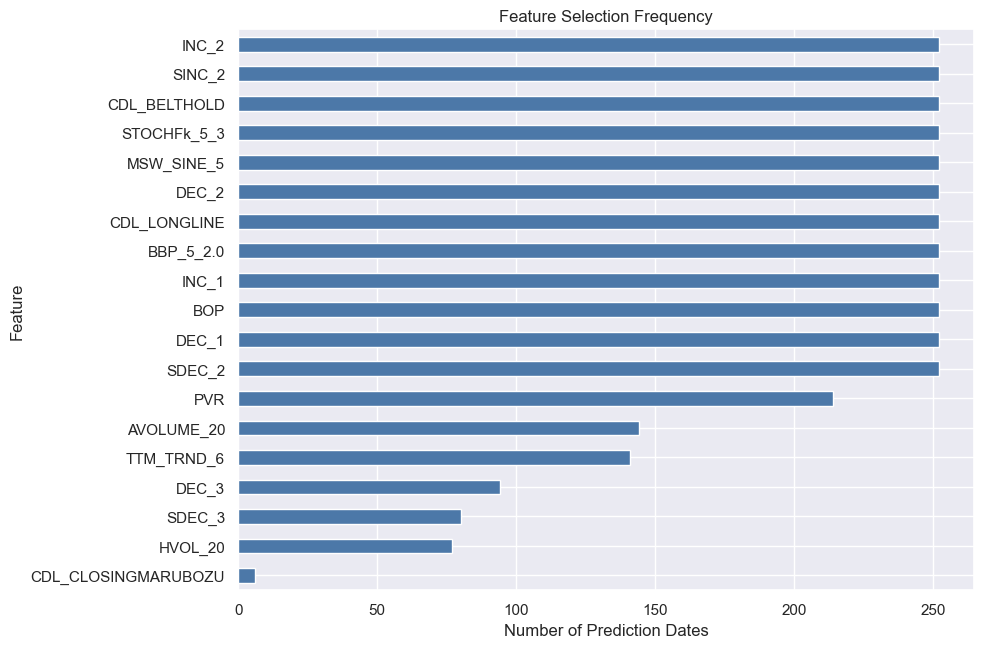

In [24]:
# Frequency graph of selected features in the configured prediction window.
ax = strategy.plot_feature_frequency(top_n=30, selected_only=True)
plt.show()

### Frequency Table

The table view is useful when you want exact counts and shares instead of only the plot.

In [25]:
# Count selected-feature frequency across prediction dates.
selected_rows = prediction_window_diagnostics[prediction_window_diagnostics["selected"]].copy()
n_prediction_dates = selected_rows["prediction_date"].nunique()

feature_frequency = selected_rows["feature"].value_counts().rename("selected_days").to_frame()
feature_frequency["selected_share"] = feature_frequency["selected_days"] / n_prediction_dates

display(feature_frequency.head(30))

,selected_days,selected_share
feature,,
BOP,252,1.000000
CDL_BELTHOLD,252,1.000000
STOCHFk_5_3,252,1.000000
MSW_SINE_5,252,1.000000
DEC_2,252,1.000000
CDL_LONGLINE,252,1.000000
BBP_5_2.0,252,1.000000
INC_1,252,1.000000
SINC_2,252,1.000000


### Highest-Correlating Features

This summarizes the absolute Pearson correlation scores recorded by `SelectKBest`. These are training-window scores, recomputed for each prediction date.

In [26]:
# Summarize feature scores across dates.
score_summary = (
    prediction_window_diagnostics
    .groupby("feature")
    .agg(
        mean_abs_corr=("pearson_abs_corr", "mean"),
        median_abs_corr=("pearson_abs_corr", "median"),
        selected_days=("selected", "sum"),
        seen_days=("prediction_date", "nunique"),
    )
    .sort_values(["selected_days", "mean_abs_corr"], ascending=False)
)

display(score_summary.head(30))

,mean_abs_corr,median_abs_corr,selected_days,seen_days
feature,,,,
BOP,0.103965,0.102628,252,252
CDL_BELTHOLD,0.091033,0.089679,252,252
DEC_1,0.090795,0.089471,252,252
DEC_2,0.090795,0.089471,252,252
SDEC_2,0.090795,0.089471,252,252
CDL_LONGLINE,0.087870,0.087506,252,252
INC_1,0.086374,0.084214,252,252
INC_2,0.086374,0.084214,252,252
SINC_2,0.086374,0.084214,252,252


### Inspect One Prediction Date

Use this to see the ranked feature scores for a specific model fit.

In [27]:
# Change this date to inspect another daily model fit.
date_to_check = selected_features_df["prediction_date"].iloc[0]

one_day_features = (
    prediction_window_diagnostics[prediction_window_diagnostics["prediction_date"].eq(date_to_check)]
    .sort_values("rank")
)

print(date_to_check.date())
display(one_day_features)

2024-01-02


,prediction_date,feature,pearson_abs_corr,rank,selected
0,2024-01-02,BOP,0.103608,1,True
1,2024-01-02,DEC_2,0.093959,2,True
2,2024-01-02,SDEC_2,0.093959,3,True
3,2024-01-02,DEC_1,0.093959,4,True
4,2024-01-02,INC_2,0.090340,5,True
...,...,...,...,...,...
427,2024-01-02,SINC_10,0.000050,428,False
428,2024-01-02,INC_10,0.000050,429,False
429,2024-01-02,CDL_TRISTAR,0.000047,430,False
430,2024-01-02,CDL_3WHITESOLDIERS,0.000035,431,False


In [28]:
play_sound()